# Assignment 3: LLMs and Machine Learning

## Statement of AI use
I used Claude as an assistant with coding. I specifically used it to correct bugs, debugging JSON parsing and with setting up Ollama. I double-checked everything and made sure I know what every step does. In task 2 C I also used Claude to do the comparison with a browser-based LLM.

## Task 0 

In [1]:
# Setting up Ollama first 
%pip install ollama

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importing needed libraries in this task 
import json
import pandas as pd
import ollama

### a) Connect to Ollama using Ollama's Python API

In [3]:
def ask_llm(prompt, model):
    response = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    return response["message"]["content"]

### b) Test gemma3:270m

In [4]:
print(ask_llm("What colour is the sky.", "gemma3:270m"))

The sky is blue.



### c) Test gemma3:4b

In [6]:
print(ask_llm("can I win in a fight against a bear, one word", "gemma3:4b"))

Unlikely.


## Task 1: Text classification with Ollama

### a) Classification function

In [7]:
# Loading emails first
emails = pd.read_csv("data/emails.csv", sep="\t")
display(emails)

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review
5,"Q3 budget report attached, please review by Fr..."
6,Reminder: Annual performance review scheduled ...
7,"Updated draft of the manuscript, comments welcome"
8,Quick question about last week
9,Following up


In [17]:
# Returns one of: spam / work / unknown

def classify_email(headline, model):
    prompt = (
        f"Classify this email headline as one of: spam, work, unknown.\n"
        f"Reply with only the category word.\n\n"
        f"Headline: {headline}"
    )
    answer = ask_llm(prompt, model).strip().lower()
    
    for label in ["spam", "work", "unknown"]:
        if label in answer:
            return label
    return "unknown"

In [ ]:
# Testing
classify_email("URGENT: Your account will be suspended within 24 hours", "gemma3:270m")

'unknown'

### b) Classify with gemma3:270m

In [20]:
emails["small_model"] = emails["headline"].apply(lambda h: classify_email(h, "gemma3:270m"))
display(emails[["headline", "small_model"]])

,headline,small_model
0,URGENT: Your account will be suspended within ...,work
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,work
4,Meeting agenda for Thursday's project review,work
5,"Q3 budget report attached, please review by Fr...",spam
6,Reminder: Annual performance review scheduled ...,work
7,"Updated draft of the manuscript, comments welcome",unknown
8,Quick question about last week,work
9,Following up,work


It is terrible, 4/12.

### c) Classify with the larger model (gemma3:4b)

In [21]:
emails["large_model"] = emails["headline"].apply(lambda h: classify_email(h, "gemma3:4b"))
display(emails[["headline", "small_model", "large_model"]])

,headline,small_model,large_model
0,URGENT: Your account will be suspended within ...,work,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,work,spam
4,Meeting agenda for Thursday's project review,work,work
5,"Q3 budget report attached, please review by Fr...",spam,work
6,Reminder: Annual performance review scheduled ...,work,work
7,"Updated draft of the manuscript, comments welcome",unknown,work
8,Quick question about last week,work,unknown
9,Following up,work,unknown


### Comparison of small vs. large model 

The 4b model did much better, getting 10 of 12 emails right. The 270m model only got 4 correct and labeled most of the vague ones as work. The 4b model nailed all 4 spam and all 4 work emails, and got 2 of the 4 vague ones right. The two it missed (rows 10 and 11) were "Important update regarding your recent activity" and "Are you available?", which it called spam. Those phrases do show up in real phishing so the mistake makes sense.

### d) Repeat b) and c) 3 times each, store results in one DataFrame

In [22]:
N_RUNS = 3
results = pd.DataFrame({"headline": emails["headline"]})

for run in range(1, N_RUNS + 1):
    results[f"small_run{run}"] = emails["headline"].apply(
        lambda h: classify_email(h, "gemma3:270m")
    )
    results[f"large_run{run}"] = emails["headline"].apply(
        lambda h: classify_email(h, "gemma3:4b")
    )

display(results)

,headline,small_run1,large_run1,small_run2,large_run2,small_run3,large_run3
0,URGENT: Your account will be suspended within ...,work,spam,work,spam,work,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam,spam,work,spam
2,Hot singles in your area are waiting to meet y...,work,spam,work,spam,work,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,work,spam,work,spam,work,spam
4,Meeting agenda for Thursday's project review,work,work,work,work,work,work
5,"Q3 budget report attached, please review by Fr...",work,work,work,work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work,work,work,work
7,"Updated draft of the manuscript, comments welcome",work,work,unknown,work,unknown,work
8,Quick question about last week,work,unknown,spam,unknown,work,work
9,Following up,work,work,spam,work,work,unknown


### Comments on task d)

Both models flipped their answers on some rows across the 3 runs. The 270m model was unstable on rows 1, 7, 8, 9, 10 and 11. The 4b model was mostly stable but disagreed with itself on rows 8 and 9, both of which are vague headlines.

This happens because LLMs add some randomness when generating answers, so the same prompt can give different outputs each time. The variation shows up most on borderline cases where the model is roughly equally torn between two labels

## Task 2: Sentiment analysis with Ollama

### a) Classification function

In [29]:
# Returns topic and sentiment as a JSON string
def classify_news(headline, model):
    prompt = (
        f"Classify the financial news headline below.\n"
        f"Reply with ONLY a JSON object with two keys:\n"
        f'"topic": one of [earnings, mergers, regulation, macroeconomics]\n'
        f'"sentiment": one of [positive, negative, neutral]\n\n'
        f"Headline: {headline}"
    )
    answer = ask_llm(prompt, model).strip()
    if answer.startswith("```"):
        answer = answer.strip("`").lstrip("json").strip()
    return " ".join(answer.split())

In [30]:
# Testing
classify_news("NorthBay Industries posts record Q4 earnings, beats analyst estimates by 18%", "gemma3:4b")

'{ "topic": "earnings", "sentiment": "positive" }'

### b) Classifying the news

In [31]:
# Classifying all 10 headlines using gemma3:4b
# First lets load news 
news = pd.read_csv("data/news.csv", sep="\t")
display(news)

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,"Eurozone inflation cools to 2.1%, easing press..."
9,Rising interest rates weigh on Tessaro Real Es...


In [33]:
# Classifying each headline and pull topic + sentiment into their own columns
classifications = news["headline"].apply(lambda h: classify_news(h, "gemma3:4b"))
parsed = classifications.apply(json.loads)

news["topic"] = parsed.apply(lambda d: d["topic"])
news["sentiment"] = parsed.apply(lambda d: d["sentiment"])

display(news)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,neutral
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,neutral
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,neutral
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


### c) Comparison with Claude

I asked Claude to perform the same classification task with the same options for topic and sentiment. Its results:

| # | Headline | Topic | Sentiment |
|---|----------|-------|-----------|
| 1 | Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| 2 | Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| 3 | Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| 4 | Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | positive |
| 5 | Antitrust regulators block proposed merger between Solenta and Marvex Energy | mergers | negative |
| 6 | Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| 7 | New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| 8 | Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| 9 | Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| 10 | Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics | negative |

The two models agreed on 5 of 10 headlines. They disagreed mostly on sentiment: in 4 cases gemma3:4b said neutral while Claude picked positive or negative based on cues like "easing pressure" or "in line with expectations". They also disagreed on row 5 where gemma3 said regulation and Claude said mergers. Both are fine since the headline is about a merger being blocked by regulators.

Claude was more accurate overall because it commits to a sentiment when the headline implies one. That makes sense since Claude is a much larger model than gemma3:4b. The trade-off is that gemma3:4b runs locally and is free.

## Task 3: Supervised machine learning

### a) Exploratory data analysis

In [34]:
# Importing the libraries used for Task 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset, the CSV uses semicolons 
df = pd.read_csv("data/bank-additional.csv", sep=";")

print("Shape:", df.shape)
df.head()

Shape: (4119, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [ ]:
# Basic info
df.info()
display(df.describe())

# Target balance
print("\nTarget class balance:")
print(df["y"].value_counts(normalize=True).round(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



Target class balance:
y
no     0.891
yes    0.109
Name: proportion, dtype: float64


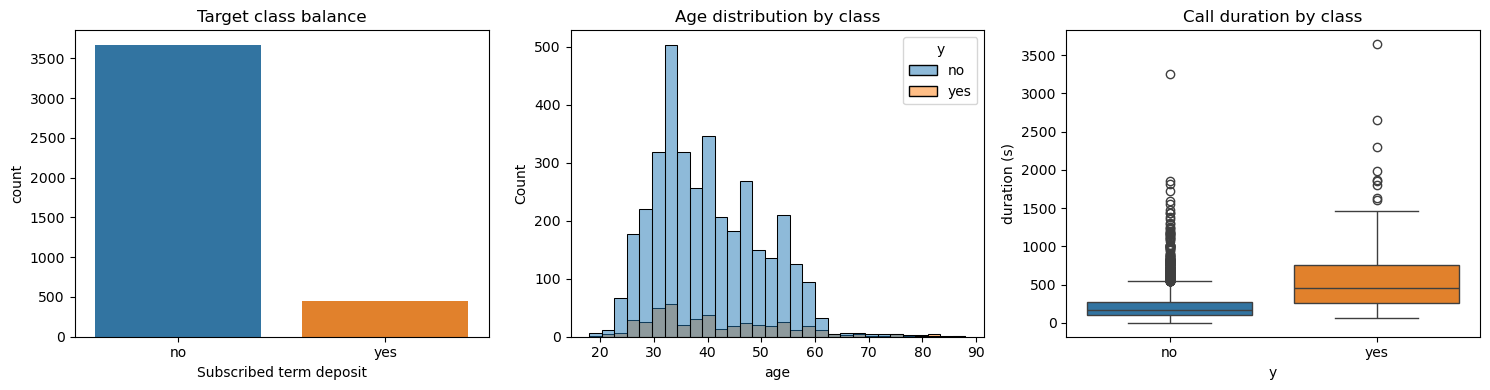

In [38]:
# Quick visualizations: target balance, age, call duration
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x="y", hue="y", legend=False, ax=axes[0])
axes[0].set_title("Target class balance")
axes[0].set_xlabel("Subscribed term deposit")

sns.histplot(data=df, x="age", hue="y", bins=30, ax=axes[1])
axes[1].set_title("Age distribution by class")

sns.boxplot(data=df, x="y", y="duration", hue="y", legend=False, ax=axes[2])
axes[2].set_title("Call duration by class")
axes[2].set_ylabel("duration (s)")

plt.tight_layout()
plt.show()

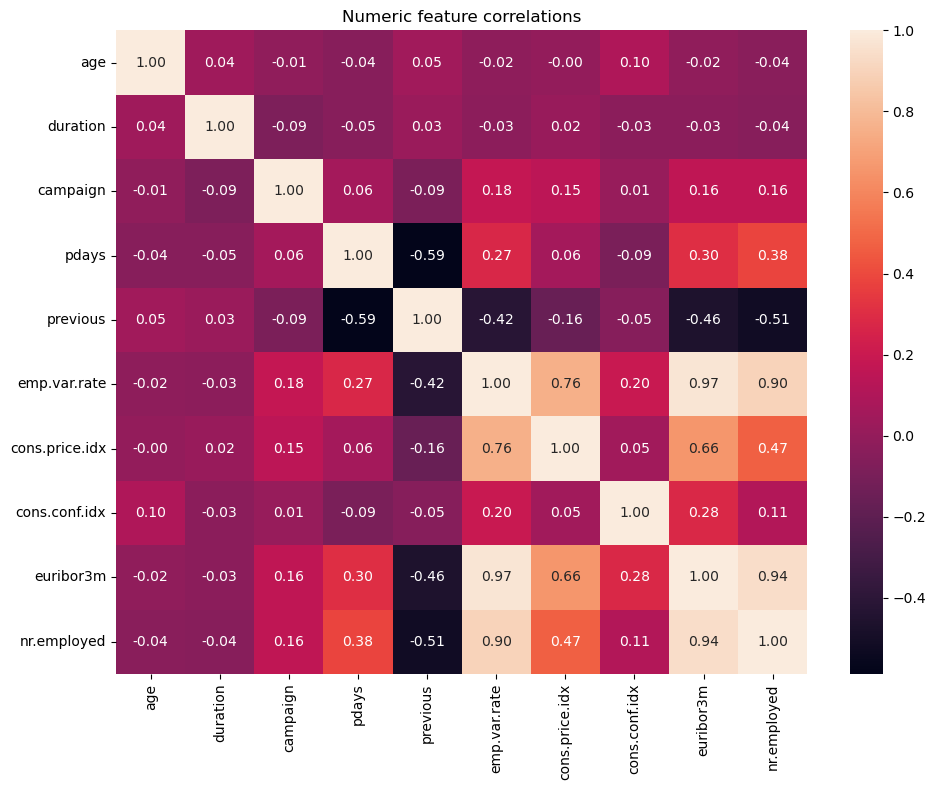


Missing values coded as 'unknown':
  job: 39 (0.9%)
  marital: 11 (0.3%)
  education: 167 (4.1%)
  default: 803 (19.5%)
  housing: 105 (2.5%)
  loan: 105 (2.5%)


In [39]:
# Correlation heatmap of numeric features
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, fmt=".2f")
plt.title("Numeric feature correlations")
plt.tight_layout()
plt.show()

# Check the 'unknown' values - dataset uses literal string instead of NaN
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("\nMissing values coded as 'unknown':")
for col in cat_cols:
    n_unknown = (df[col] == "unknown").sum()
    if n_unknown > 0:
        print(f"  {col}: {n_unknown} ({n_unknown / len(df) * 100:.1f}%)")

### b) Preprocessing the data

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dropping the 'duration' column
data = df.drop(columns=["duration"]).copy()

# Treating 'unknown' as its own category
data = data.replace("unknown", "missing")

# Encoding the target y as 0/1
data["y"] = data["y"].map({"yes": 1, "no": 0})

# Turning text categories into 0/1 columns
nominal_cols = ["job", "marital", "education", "default", "housing", "loan",
                "contact", "month", "day_of_week", "poutcome"]
data = pd.get_dummies(data, columns=nominal_cols, drop_first=True, dtype=float)

# Splitting features and target
y = data["y"]
X = data.drop(columns=["y"])

# 60/20/20 train/val/test split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Standardizing the numeric features
numeric_cols = ["age", "campaign", "pdays", "previous",
                "emp.var.rate", "cons.price.idx", "cons.conf.idx",
                "euribor3m", "nr.employed"]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols]   = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("\nClass balance in train:")
print(y_train.value_counts(normalize=True).round(3))

Train: (2471, 52) Val: (824, 52) Test: (824, 52)

Class balance in train:
y
0    0.893
1    0.107
Name: proportion, dtype: float64


### c) Choosing and training three classifiers

This is a classification task because the target variable y is binary, which means it has two outcomes: yes and no. I will use logistic regression as a baseline model, then a random forest model because it can be used to model non-linear relationships and finally a SVM model to see how a kernel-based classifier compares. Since the dataset is imbalanced (~89% no, ~11% yes) I use class_weight="balanced" and tune the hyperparameters with GridSearchCV optimising for recall, same approach as in exercise 6. 

In [41]:
# Logistic Regression with grid search
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
}

grid_lr = GridSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42),
    param_grid_lr, cv=5, scoring="recall", n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print("Best LR parameters:", grid_lr.best_params_)
print("Best LR Recall (CV):", f"{grid_lr.best_score_:.4f}")

y_pred_lr_tuned = grid_lr.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_lr_tuned):.4f}")

Best LR parameters: {'C': 0.01}
Best LR Recall (CV): 0.6566
Validation Recall: 0.5957


In [42]:
# Random Forest with grid search
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "bootstrap": [True, False],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid_rf, cv=5, scoring="recall", n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print("Best RF parameters:", grid_rf.best_params_)
print("Best RF Recall (CV):", f"{grid_rf.best_score_:.4f}")

y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_rf_tuned):.4f}")

Best RF parameters: {'bootstrap': False, 'max_depth': 5, 'n_estimators': 100}
Best RF Recall (CV): 0.5962
Validation Recall: 0.5745


In [43]:
# SVM with grid search
from sklearn.svm import SVC

param_grid_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1],
    "kernel": ["rbf"],
}

grid_svm = GridSearchCV(
    SVC(class_weight="balanced", random_state=42),
    param_grid_svm, cv=5, scoring="recall", n_jobs=-1
)
grid_svm.fit(X_train, y_train)

print("Best SVM parameters:", grid_svm.best_params_)
print("Best SVM Recall (CV):", f"{grid_svm.best_score_:.4f}")

y_pred_svm_tuned = grid_svm.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_svm_tuned):.4f}")

Best SVM parameters: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
Best SVM Recall (CV): 0.7170
Validation Recall: 0.6702


The SVM model performed best with a validation recall of 0.6702, followed
by Logistic Regression at 0.5957 and Random Forest at 0.5745. SVM also had
the highest cross-validation recall (0.7170). After several rounds of
hyperparameter tuning the scores stopped improving, so I kept the parameters
shown above. Recall is the most relevant metric here because the goal is to
identify customers likely to subscribe, and missing those is more costly
than calling someone who eventually says no.

### d) Train, validation and test set split versus cross-validation

In [44]:
# Compare train/val/test split with 5-fold cross-validation
from sklearn.model_selection import cross_val_score

# Logistic Regression
cv_lr = cross_val_score(grid_lr.best_estimator_, X_train, y_train, cv=5, scoring="recall", n_jobs=-1)
print("Logistic Regression")
print(f"Train/val/test split-Validation Recall: {recall_score(y_val,  y_pred_lr_tuned):.4f}")
print(f"Train/val/test split-Test Recall:       {recall_score(y_test, grid_lr.best_estimator_.predict(X_test)):.4f}")
print(f"5-fold cross-validation-Recall:         {cv_lr.mean():.4f} (+/- {cv_lr.std():.4f})")
print()

# Random Forest
cv_rf = cross_val_score(grid_rf.best_estimator_, X_train, y_train, cv=5, scoring="recall", n_jobs=-1)
print("Random Forest")
print(f"Train/val/test split-Validation Recall: {recall_score(y_val,  y_pred_rf_tuned):.4f}")
print(f"Train/val/test split-Test Recall:       {recall_score(y_test, grid_rf.best_estimator_.predict(X_test)):.4f}")
print(f"5-fold cross-validation-Recall:         {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")
print()

# SVM
cv_svm = cross_val_score(grid_svm.best_estimator_, X_train, y_train, cv=5, scoring="recall", n_jobs=-1)
print("SVM")
print(f"Train/val/test split-Validation Recall: {recall_score(y_val,  y_pred_svm_tuned):.4f}")
print(f"Train/val/test split-Test Recall:       {recall_score(y_test, grid_svm.best_estimator_.predict(X_test)):.4f}")
print(f"5-fold cross-validation-Recall:         {cv_svm.mean():.4f} (+/- {cv_svm.std():.4f})")

Logistic Regression
Train/val/test split-Validation Recall: 0.5957
Train/val/test split-Test Recall:       0.6630
5-fold cross-validation-Recall:         0.6566 (+/- 0.0690)

Random Forest
Train/val/test split-Validation Recall: 0.5745
Train/val/test split-Test Recall:       0.6522
5-fold cross-validation-Recall:         0.5962 (+/- 0.0681)

SVM
Train/val/test split-Validation Recall: 0.6702
Train/val/test split-Test Recall:       0.6957
5-fold cross-validation-Recall:         0.7170 (+/- 0.0597)


For all three models the validation recall is several percent lower than both
the test recall and the CV mean (e.g. LR: 0.60 validation, 0.66 test, 0.66 CV).
The CV std is around 6-7%, which shows how much a single split can swing.
Cross-validation is the more reliable approach because it averages over 5
splits instead of relying on one. The model ranking is the same either way:
SVM is best, then LR, then RF.

### e) Evaluation of the models

In [45]:
# Final evaluation on the test set
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_models = {
    "Logistic Regression": grid_lr.best_estimator_,
    "Random Forest":       grid_rf.best_estimator_,
    "SVM":                 grid_svm.best_estimator_,
}

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    print(f"{name}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
    print()

Logistic Regression
Accuracy:  0.7900
Precision: 0.3005
Recall:    0.6630
F1-score:  0.4136

Random Forest
Accuracy:  0.8617
Precision: 0.4225
Recall:    0.6522
F1-score:  0.5128

SVM
Accuracy:  0.7233
Precision: 0.2424
Recall:    0.6957
F1-score:  0.3596



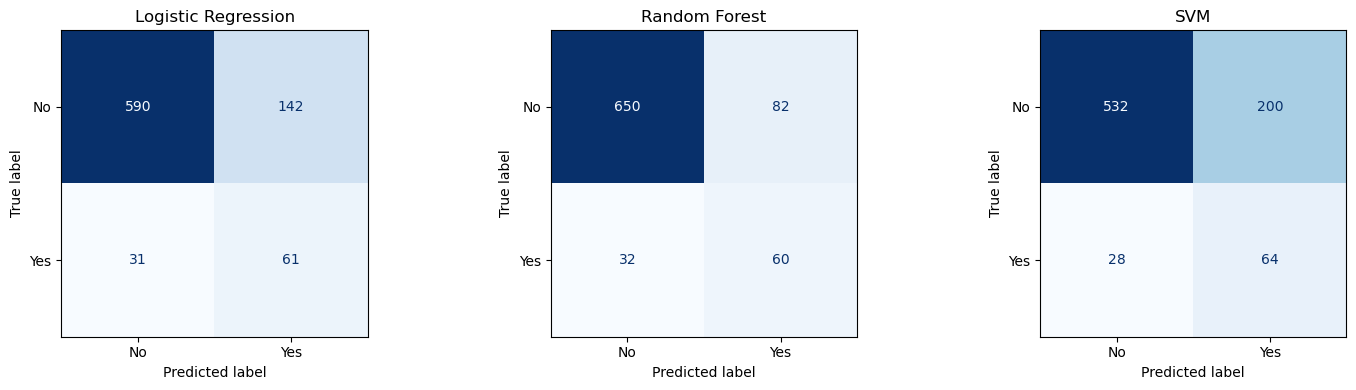

In [46]:
# Confusion matrices for the three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, best_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}")

plt.tight_layout()
plt.show()

Which model is best?

Random Forest. It has the highest accuracy (0.86), the highest precision (0.42)
and the highest F1-score (0.51) on the test set, which means it catches a good
share of the subscribers (60/92) without wasting too many calls on people who
say no (82 false alarms). SVM has slightly higher recall but its precision is
much worse, so most of the people it flags would not actually subscribe.
Accuracy alone is misleading here because the dataset is imbalanced. F1 is
the more honest metric, and Random Forest wins on it.
